In [167]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [168]:
# Leitura do arquivo

caminho_arquivo = 'tratados_10x10det/carbon/carbon1E17_array'

df = pl.read_csv(caminho_arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 0 0 0 0""","[""TRIG2"", ""0"", … ""0""]","""TRIG2""",0,0,0,0,0
"""TRIG3 0 0 0 0""","[""TRIG3"", ""0"", … ""0""]","""TRIG3""",0,0,0,0,0
"""TRIG4 0 0 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,0,0,0,0
"""TRIG5 0 0 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,0,0,0,0
…,…,…,…,…,…,…,…
"""TRIG96 0 0 0 0""","[""TRIG96"", ""0"", … ""0""]","""TRIG96""",0,0,0,0,0
"""TRIG97 0 0 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,0,0,0,0
"""TRIG98 0 0 0 0""","[""TRIG98"", ""0"", … ""0""]","""TRIG98""",0,0,0,0,0


In [169]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Carbon 1E17'

In [170]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

#print("x_det:", x_det)
#print("y_det:", y_det)
#print("areas:", areas)

In [171]:
from scipy.spatial import KDTree

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)

# Método KDTree 
positions = np.column_stack((x_det, y_det))
tree = KDTree(positions)
d_max = 15  # Distância máxima para considerar como próximos

# Validar simulações com triangulação
num_simulations = len(df2["total_particles"][0])

valid_simulations = []

for sim_idx in range(num_simulations):
    detections = np.array([df2["total_particles"][i][sim_idx] > 0 for i in range(100)])  

    detected_indices = np.where(detections)[0]
    if len(detected_indices) < 3:
        continue
    
    neighbors = []
    for tank in detected_indices:
        neighbors.append(set(tree.query_ball_point(positions[tank], d_max)))
    
    valid = False
    n = len(detected_indices)
    for i in range(n):
        tank_i = detected_indices[i]
        for j in range(i + 1, n):
            tank_j = detected_indices[j]
            if tank_j not in neighbors[i]:  
                continue
            for k in range(j + 1, n):
                tank_k = detected_indices[k]
                if tank_k in neighbors[i] and tank_k in neighbors[j]:
                    valid = True
                    break
            if valid:
                break
        if valid:
            break
    
    if valid:
        valid_simulations.append(sim_idx)


# Atualizar o dataframe
triangulation_particles = [
    [particles[i] for i in valid_simulations] for particles in df2["total_particles"]
]

triangulation_particles = df2.with_columns(
    pl.Series("triangulation_particles", triangulation_particles)
)

print(f"Simulações válidas: {len(valid_simulations)}")
triangulation_particles

Simulações válidas: 677


TRIG,total_particles,triangulation_particles
str,list[i64],list[i64]
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG2""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG3""","[0, 482, … 0]","[0, 482, … 0]"
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG5""","[0, 0, … 0]","[0, 0, … 0]"
…,…,…
"""TRIG96""","[0, 515, … 0]","[0, 515, … 0]"
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]"


In [172]:
triangulation_particles = triangulation_particles.with_columns(mean_particles = pl.col('triangulation_particles').list.mean())  
trigs = triangulation_particles['mean_particles'].to_list()
triangulation_particles

TRIG,total_particles,triangulation_particles,mean_particles
str,list[i64],list[i64],f64
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]",68.994092
"""TRIG2""","[0, 0, … 0]","[0, 0, … 0]",112.646972
"""TRIG3""","[0, 482, … 0]","[0, 482, … 0]",147.533235
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]",164.258493
"""TRIG5""","[0, 0, … 0]","[0, 0, … 0]",167.71935
…,…,…,…
"""TRIG96""","[0, 515, … 0]","[0, 515, … 0]",183.771049
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]",159.485968
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]",134.865583


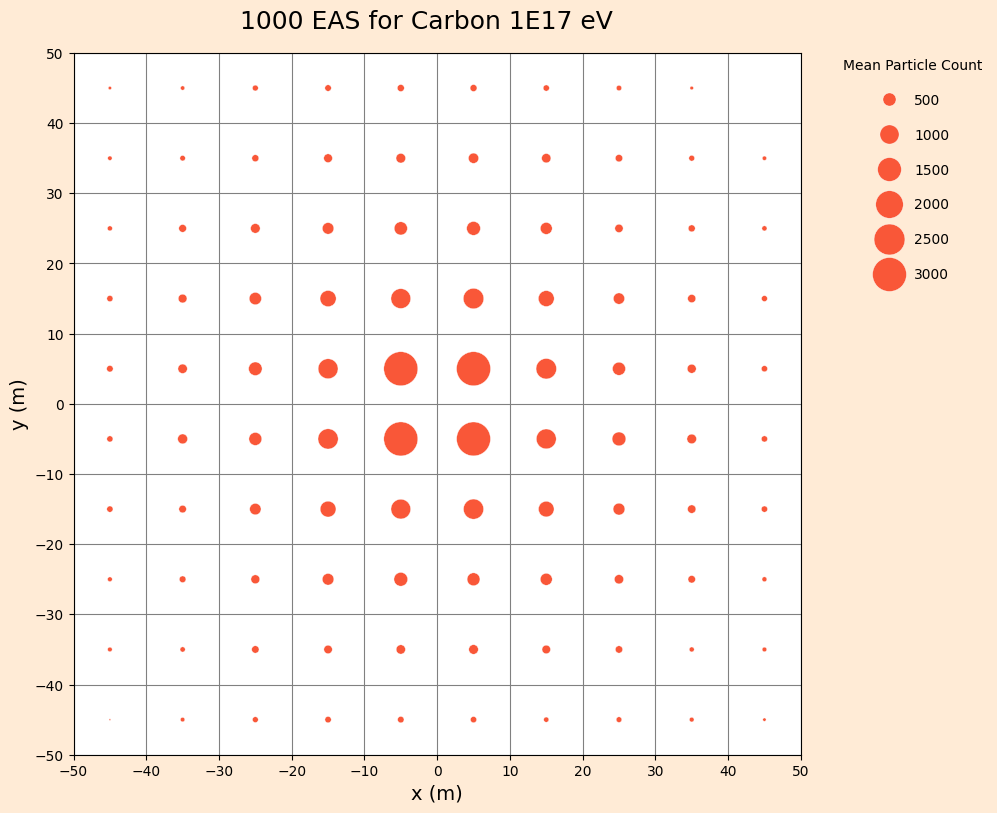

In [173]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('1000 EAS for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Mean Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


plt.savefig('plots/' + name.split(' ')[0].lower() + '/counts_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png', bbox_inches = 'tight', dpi = 300)

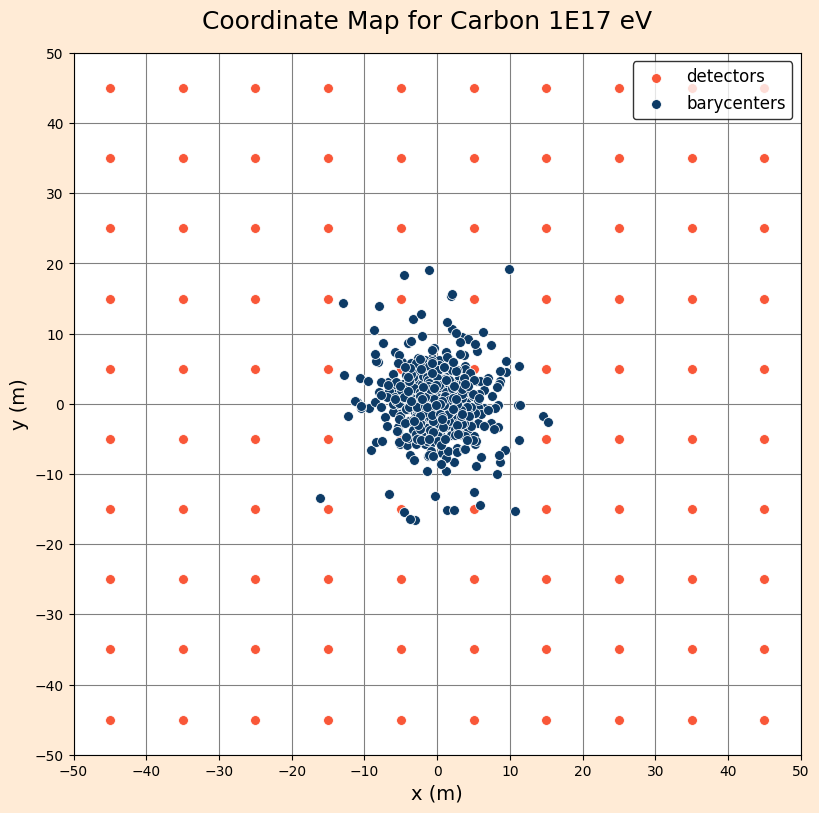

In [174]:
# Posição dos baricentros
x_b = [0] * len(valid_simulations)
y_b = [0] * len(valid_simulations)
rho = []

for i in range(len(valid_simulations)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (triangulation_particles['triangulation_particles'][j][i]*x_det[j])
                numerator1 += (triangulation_particles['triangulation_particles'][j][i]*y_det[j])
                denominator += (triangulation_particles['triangulation_particles'][j][i])
                rho.append((triangulation_particles['triangulation_particles'][j][i])/1)
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/map_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png',bbox_inches = 'tight', dpi = 300)

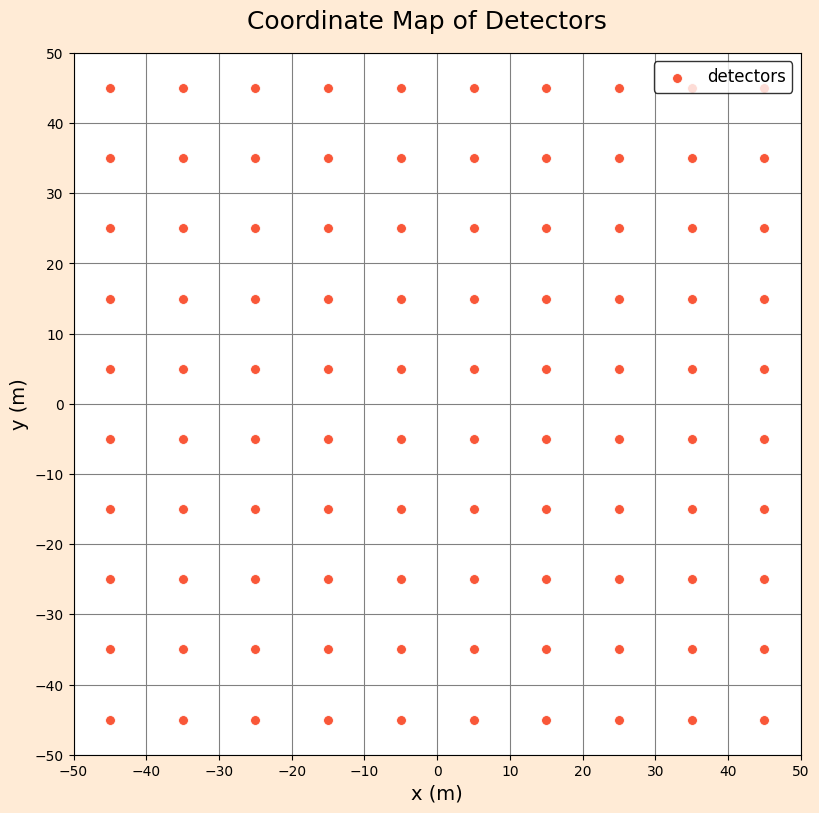

In [175]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

In [176]:
i = 4
eas = 1000
area_detectores = 100
area_total = (np.pi*100**2)
total_particles = [4072360, 5608623, 2.48145e+08, 9.64801e+08, 3.93289e+09]
part = total_particles[i]/eas * (area_detectores/area_total)
part

12518.777682733686

[4.88600544e+06 1.82187048e+00]
[1.73464027 2.07208489 2.86442331 3.52334232 4.10868379]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_23516\3392358090.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


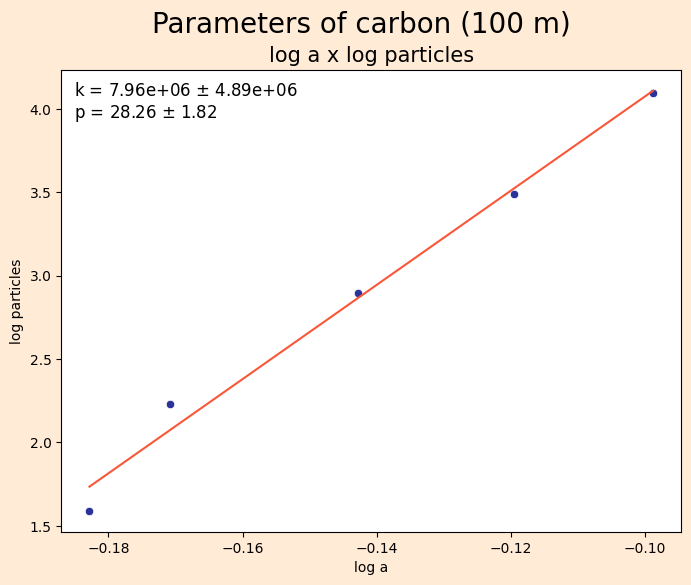

In [177]:
from scipy.optimize import curve_fit

# Fit do carbono

a = [0.6564, 0.6747, 0.7197, 0.7594, 0.7965]

particles = [38.92710054352618, 170.02668083598005, 789.8700670707674, 3071.0569650000743, 12518.777682733686]

E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

loga = np.log10(a)
logparticles = np.log10(particles)
#logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log a x log particles', size = 15)
ax.set_xlabel('log a')
ax.set_ylabel('log particles')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, a, np.log10(particles), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(a,*coefficients_carbon))

ax.plot(loga, power(a,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = loga, y = logparticles, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

In [178]:
r_b = [] 

# Estruturação da lista rho para 100 tanques
rho_reshaped = np.array(rho).reshape(len(x_b), 100)


for i in range(len(valid_simulations)):
    #aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    aux = x_b[i]** 2 + y_b[i]**2
    r_b.append(aux)

data = {
    'x_b':x_b,
    'y_b':y_b,
    'r_b':r_b
}

for i in range(100):
    data[f'rho_{i+1}'] = rho_reshaped[:, i].tolist()

df = pl.DataFrame(data, strict=False)

rho_cols = [pl.col(f'rho_{i+1}') for i in range(100)]

df = df.with_columns(
    rho_total=pl.sum_horizontal(rho_cols)        
)

df = df.with_columns(
    particles_total=pl.col('rho_total') * 1
)

df = df.with_columns(
    a=(pl.col("particles_total") / coefficients_carbon[0]).pow(1 / coefficients_carbon[1])
)

distance_bary = []
for i in range(100):
    x = x_det[i]
    y = y_det[i]
    expr = ((pl.col("x_b") - x)**2 + (pl.col("y_b") - y)**2).sqrt().alias(f"r{i+1}_b")
    distance_bary.append(expr)

df = df.with_columns(distance_bary)

# Reordenar colunas
df = df.select([
    'x_b', 
    'y_b', 
    'r_b', 
    'rho_total', 
    'particles_total', 
    'a',
    *[f'r{i+1}_b' for i in range(100)],
    *[f'rho_{i+1}' for i in range(100)]
])

df

x_b,y_b,r_b,rho_total,particles_total,a,r1_b,r2_b,r3_b,r4_b,r5_b,r6_b,r7_b,r8_b,r9_b,r10_b,r11_b,r12_b,r13_b,r14_b,r15_b,r16_b,r17_b,r18_b,r19_b,r20_b,r21_b,r22_b,r23_b,r24_b,r25_b,r26_b,r27_b,r28_b,r29_b,r30_b,r31_b,…,rho_64,rho_65,rho_66,rho_67,rho_68,rho_69,rho_70,rho_71,rho_72,rho_73,rho_74,rho_75,rho_76,rho_77,rho_78,rho_79,rho_80,rho_81,rho_82,rho_83,rho_84,rho_85,rho_86,rho_87,rho_88,rho_89,rho_90,rho_91,rho_92,rho_93,rho_94,rho_95,rho_96,rho_97,rho_98,rho_99,rho_100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.79527,-5.553936,31.478659,3087.0,3087.0,0.757311,59.245676,52.210684,46.280243,41.925724,39.669531,39.869501,42.49097,47.131603,53.26625,60.441697,53.114299,45.133515,38.117445,32.693196,29.744755,30.010929,33.414986,39.146733,46.350535,54.445179,48.292934,39.346066,31.048645,24.081606,19.895456,20.291244,25.052744,32.303953,40.736357,49.752952,45.202724,…,20.0,0.0,568.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4.745725,-0.760982,23.101001,27136.0,27136.0,0.817867,66.571224,59.471114,53.309464,48.445685,45.299778,44.239749,45.411903,48.655178,53.594887,59.812184,60.389962,52.459823,45.355469,39.524727,35.59901,34.239962,35.74158,39.781227,45.690606,52.846164,55.336852,46.553761,38.371059,31.263776,26.124876,24.240352,26.318818,31.587429,38.766624,46.988686,51.743471,…,660.0,483.0,988.0,0.0,1443.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,924.0,353.0,0.0,0.0,0.0,0.0,0.0,966.0,0.0,0.0,0.0,0.0,702.0,0.0,0.0,0.0,0.0,0.0,559.0,0.0,515.0,0.0,0.0,0.0,0.0
-0.940746,-0.404215,1.048393,104635.0,104635.0,0.857878,62.689727,56.114319,50.671804,46.759456,44.780148,44.989738,47.359175,51.591728,57.275835,64.026059,56.018624,48.547926,42.139246,37.343419,34.833115,35.102149,38.091676,43.241076,49.885926,57.510178,50.459593,42.011729,34.4064,28.330465,24.928502,25.303066,29.309726,35.747377,43.551004,52.110506,46.41395,…,0.0,1338.0,674.0,1219.0,860.0,1582.0,656.0,0.0,0.0,771.0,647.0,729.0,1275.0,1380.0,1294.0,0.0,0.0,0.0,0.0,1490.0,1241.0,424.0,461.0,0.0,0.0,0.0,606.0,502.0,0.0,0.0,870.0,625.0,0.0,0.0,0.0,625.0,1.0
2.416132,-3.700168,19.528935,50645.0,50645.0,0.836128,62.880567,55.728297,49.571367,44.821845,41.9604,41.380581,43.174412,47.071299,52.605937,59.321682,56.815219,48.78162,41.609179,35.819005,32.166419,31.406303,33.734748,38.596769,45.181721,52.849459,51.9805,43.054033,34.717822,27.513715,22.553977,21.455983,24.739373,31.043743,38.928027,47.613745,48.743982,…,0.0,1585.0,542.0,0.0,366.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3009.0,805.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,514.0,0.0,0.0,0.0,0.0,0.0,984.0,1.0,0.0,0.0,0.0,0.0
-1.010145,-1.817789,4.32475,63679.0,63679.0,0.842933,61.642605,54.95465,49.398547,45.391843,43.366142,43.598454,46.05462,50.410623,56.226629,63.100212,55.10142,47.501257,40.945968,36.010765,33.421222,33.722114,36.84269,42.161437,48.96723,56.727352,49.724464,41.142741,33.360576,27.076391,23.523049,23.948627,28.173385,34.841678,42.826924,51.520368,45.922522,…,1426.0,0.0,517.0,0.0,655.0,868.0,0.0,107.0,564.0,0.0,603.0,0.0,1970.0,1656.0,541.0,0.0,99.0,0.0,0.0,517.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,789.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.878772,2.773526,22.737319,41294.0,41294.0,0.83011,68.347964,61.594389,55.82377,51.368452,48.591588,47.786682,49.050908,52.234243,57.016144,63.033842,61.773567,54.206994,47.54811,42.228513,38.802988,37.790163,39.376656,43.277541,48.942519,55.837216,56.218352,47.779992,40.066847,33.582388,29.158213,27.796149,29.917394,34.892335,41.712104,49.621812,52.009928,…,1206.0,0.0,0.0,515.0,0.0,0.0,940.0,0.0,0

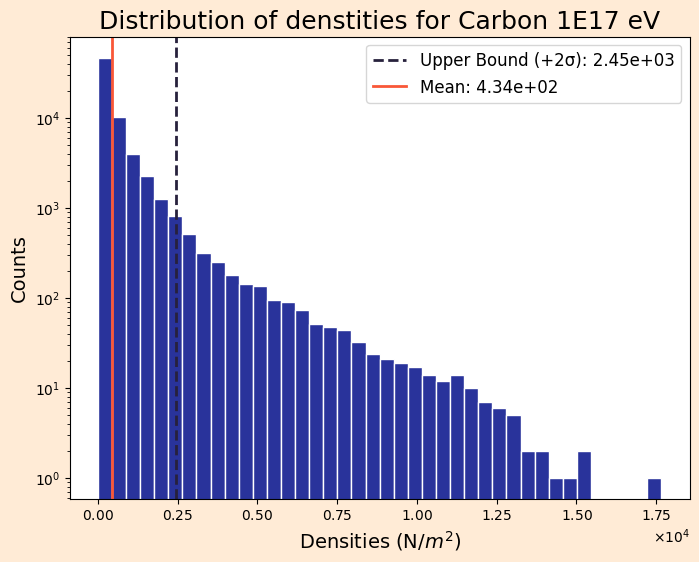

In [179]:

rho_columns = [f"rho_{i+1}" for i in range(100)] 
values = df.select(rho_columns).to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=40, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ax.set_yscale('log')


plt.title('Distribution of denstities for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Densities (N/$m^2$)', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


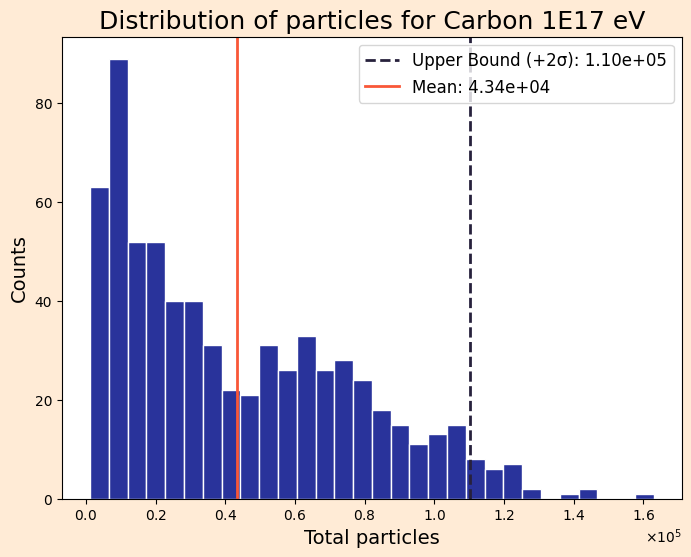

In [180]:
values = df.select('particles_total').to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=30, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)


plt.title('Distribution of particles for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Total particles', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


In [181]:
# Modelagem NKG
def model(r, C, a, b):
    r0 = 78
    return C/(r0**2)*(r/r0)**(-a)*(1+r/r0)**(-b)


parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = [f"r{i+1}_b" for i in range(100)]  
y_cols = [f"rho_{i+1}" for i in range(100)] 

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

a_std = df['a'].std()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i].flatten() 
    r = np.where(r <= 0, 1e-9, r)  
    rho = y[i].flatten()
    a_fixed = df['a'][i]

    try:
        
        def current_model(r, C, b):
            return model(r, C, a_fixed, b)
        
        popt, pcov = curve_fit(current_model, r, rho, p0= [1E5, 3] , bounds= ([0, 2.5], [np.inf, 4.0]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = current_model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append([popt[0], a_fixed, popt[1]])
        uncertainties.append([perr[0], a_std, perr[1]])
        #parameters.append(popt)
        #uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


# Cria DataFrame com todos os parâmetros
parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    'a': [p[1] for p in parameters],
    'b': [p[2] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    'a_err': [e[1] for e in uncertainties],
    'b_err': [e[2] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

# Filtra valores válidos para estatísticas
valid = parameters_df.filter(
    pl.all_horizontal(
        pl.col('C').is_not_nan(),
        pl.col('a').is_not_nan(),
        pl.col('b').is_not_nan()
    )
)
print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {valid['C'].mean():.2e} ± {valid['C'].std():.2e}")
print(f"a: Média = {valid['a'].mean():.2f} ± {valid['a'].std():.2f}")
print(f"b: Média = {valid['b'].mean():.2f} ± {valid['b'].std():.2f}")
print(f"R² Médio = {valid['R_2'].mean():.3f} ± {valid['R_2'].std():.3f}")
print(f"RMSE Médio = {valid['RMSE'].mean():.3e} ± {valid['RMSE'].std():.3e}")

shape: (677, 8)
┌───────────────┬──────────┬──────────┬──────────────┬──────────┬──────────┬──────────┬────────────┐
│ C             ┆ a        ┆ b        ┆ C_err        ┆ a_err    ┆ b_err    ┆ R_2      ┆ RMSE       │
│ ---           ┆ ---      ┆ ---      ┆ ---          ┆ ---      ┆ ---      ┆ ---      ┆ ---        │
│ f64           ┆ f64      ┆ f64      ┆ f64          ┆ f64      ┆ f64      ┆ f64      ┆ f64        │
╞═══════════════╪══════════╪══════════╪══════════════╪══════════╪══════════╪══════════╪════════════╡
│ 430422.721983 ┆ 0.757311 ┆ 4.0      ┆ 118850.85219 ┆ 0.028102 ┆ 1.865011 ┆ 0.236225 ┆ 139.157791 │
│               ┆          ┆          ┆ 2            ┆          ┆          ┆          ┆            │
│ 1.3500e6      ┆ 0.817867 ┆ 2.5      ┆ 260645.93940 ┆ 0.028102 ┆ 1.087718 ┆ 0.237304 ┆ 431.119744 │
│               ┆          ┆          ┆ 1            ┆          ┆          ┆          ┆            │
│ 7.3675e6      ┆ 0.857878 ┆ 3.235089 ┆ 579484.41941 ┆ 0.028102 ┆ 0.469345 

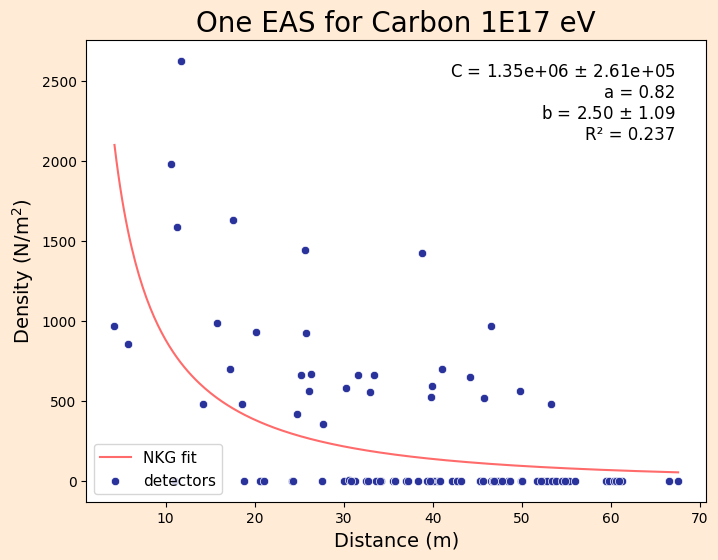

In [182]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.title('One EAS for ' + str(name) + ' eV', size = 20)
#fig.tight_layout()


#ax.set_title('log C x log E', size = 15)
ax.set_xlabel('Distance (m)', size = 14)
ax.set_ylabel('Density (N/m$^2$)', size = 14)
ax.set_facecolor('white')

i = 1

C = parameters_df['C'][i]
a = parameters_df['a'][i]
b = parameters_df['b'][i]
C_err = parameters_df['C_err'][i]
b_err = parameters_df['b_err'][i]

r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
rho_fit = model(r_smooth, C, a, b)

sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, label='NKG fit')

sns.scatterplot(x = x[i], y = y[i], color = '#29339B', ax = ax, label = 'detectors')

textstr = f'C = {C:.2e} $\pm$ {C_err:.2e}\na = {a:.2f}\nb = {b:.2f} $\pm$ {b_err:.2f}\nR² = {parameters_df["R_2"][i]:.3f}'

ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        fontsize = 12
        )

ax.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()


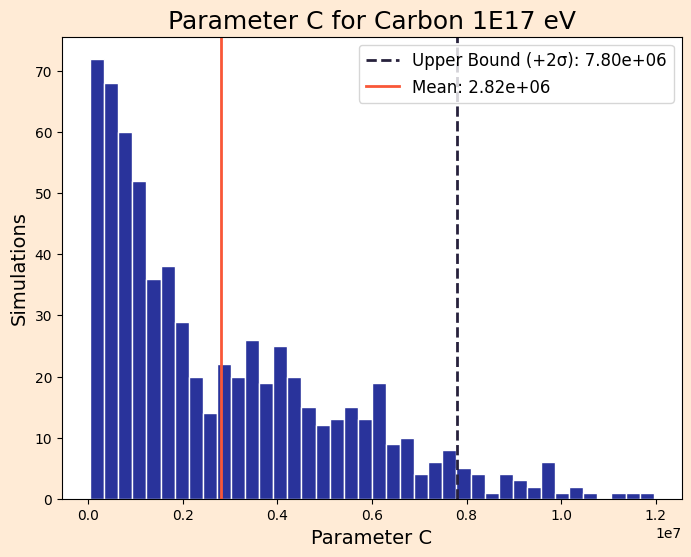

In [183]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['C'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('C')
plt.title('Parameter C for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['C'].mean()
std = parameters_df['C'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter C', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_c_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

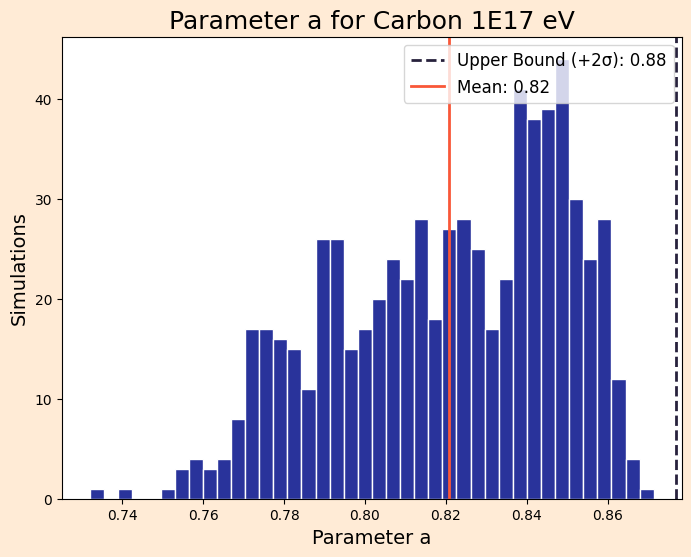

In [184]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['a'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter a for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['a'].mean()
std = parameters_df['a'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter a', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_a_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

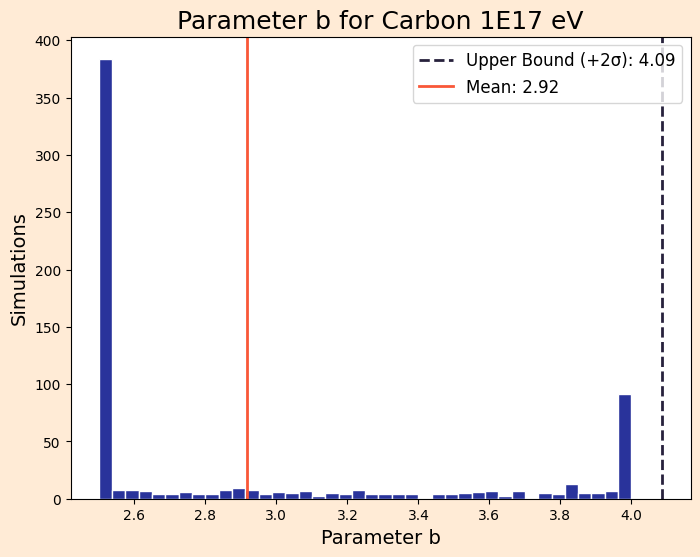

In [185]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['b'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter b for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['b'].mean()
std = parameters_df['b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter b', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_b_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

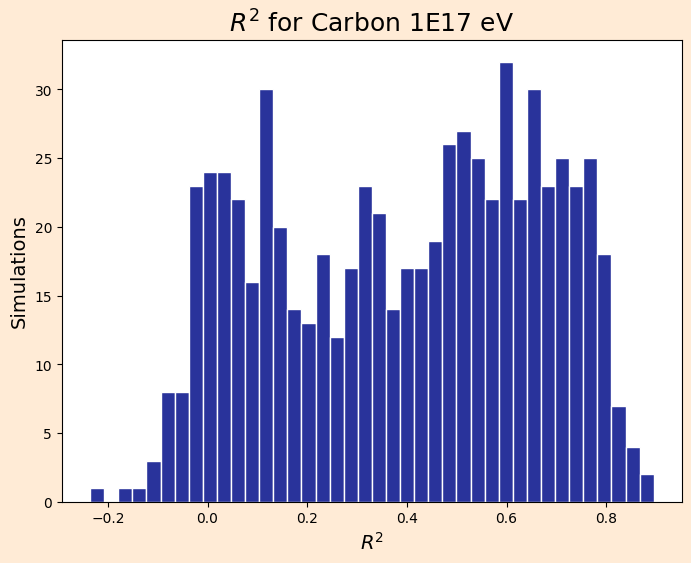

In [186]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['R_2'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('$R^2$')
plt.title('$R^2$ for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('$R^2$', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rsquared_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

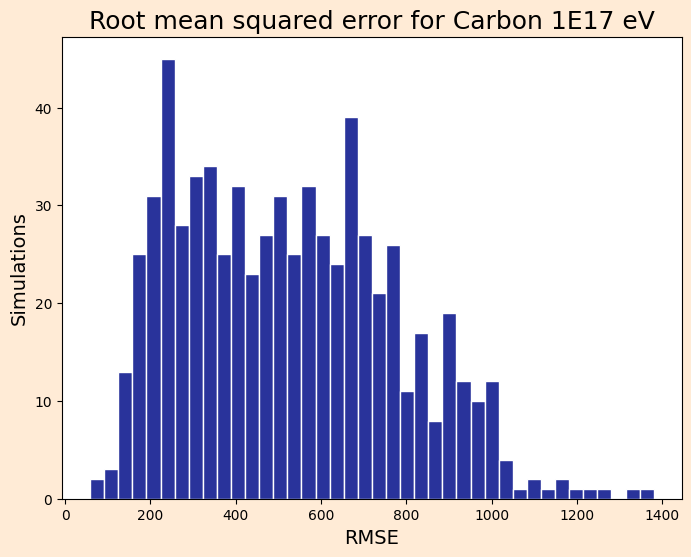

In [187]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['RMSE'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('RMSE')
plt.title('Root mean squared error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('RMSE', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rmse_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

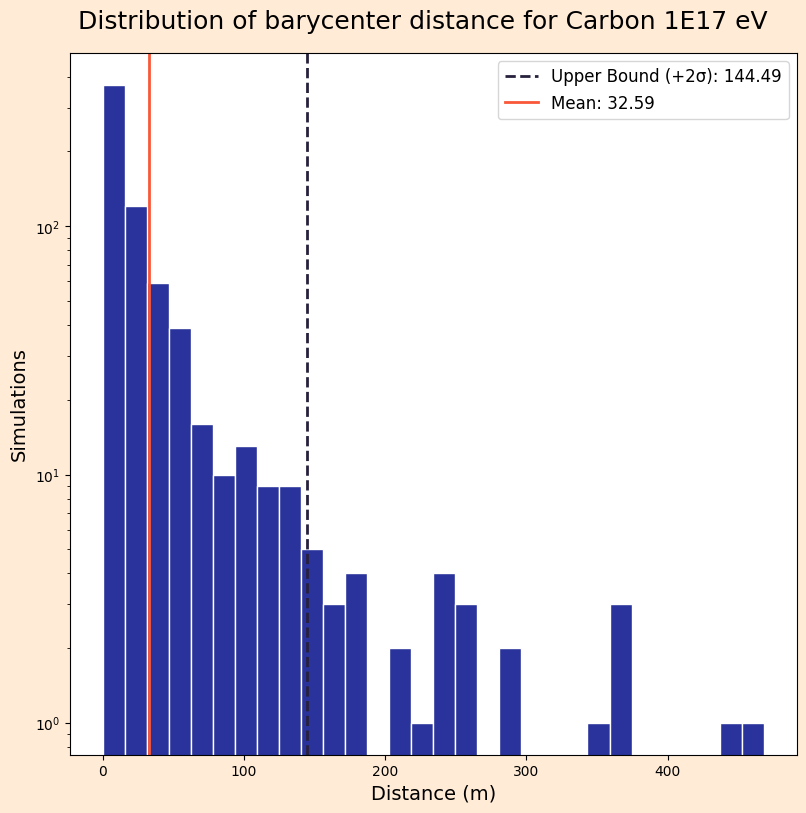

In [188]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_yscale('log')

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

plt.hist(df['r_b'], color = '#29339B', edgecolor = 'white', bins = 30)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

[2.08670076e-15 1.91271392e-02]
[3.95012984 4.56571349 5.18206812 5.79765176 6.41400639]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_23516\4227038865.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_23516\4227038865.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.921166,15.0,14.976489,0.156738
4.581495,15.499687,15.512497,0.082646
5.217484,16.0,16.028748,0.179675
5.795324,16.499687,16.497797,0.011453
6.394101,17.0,16.983842,0.095044


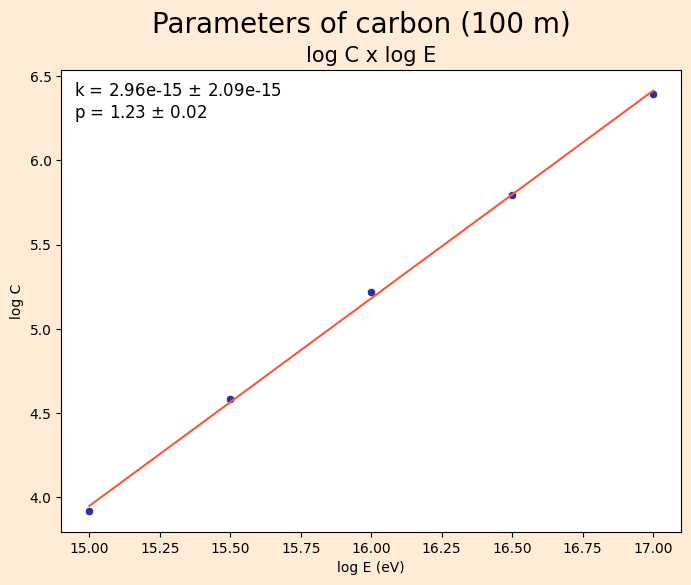

In [194]:
# Fit do carbono

C = [8340, 3.815e+04, 1.65e+05, 6.242e+05, 2.478e+06]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [190]:
k_carbon = coefficients_carbon[0] #- inc[0]
p_carbon = coefficients_carbon[1] #- inc[1]
c_carbon = parameters_df['C'] #- parameters_df['C_err']

E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_carbon)):
    E = (c_carbon[i] / k_carbon) ** (1 / p_carbon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
2.3268e16,76.731889,7.6732e16
5.8848e16,41.151521,4.1152e16
2.3333e17,133.329299,1.3333e17
9.6663e16,3.337455,3.3375e15
1.4891e17,48.90877,4.8909e16
…,…,…
8.0405e16,19.59504,1.9595e16
2.0480e17,104.798193,1.0480e17
8.3562e15,91.643752,9.1644e16


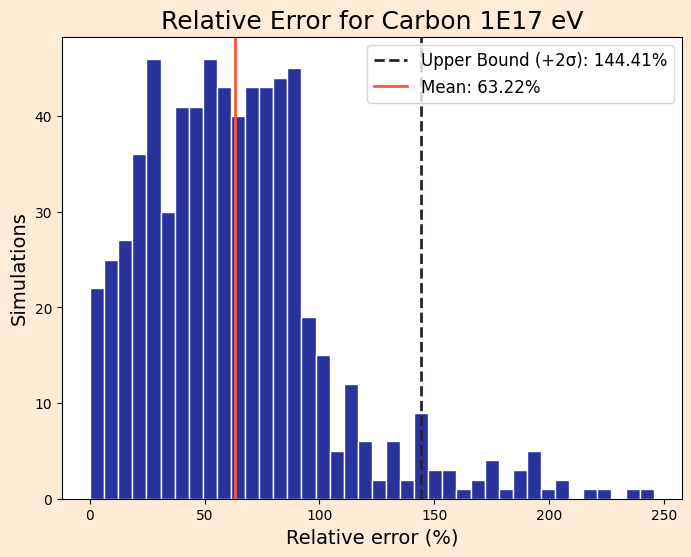

In [191]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')

In [192]:
from uncertainties import ufloat
import uncertainties.umath as umath

k_value = coefficients_carbon[0]
k_error = inc[0]  
p_value = coefficients_carbon[1]
p_error = inc[1]  

k_proton = ufloat(k_value, k_error)
p_proton = ufloat(p_value, p_error)

c_protons = [ufloat(c, c_err) for c, c_err in zip(parameters_df['C'], parameters_df['C_err'])]

E_photon_with_errors = []

E_real = float(name.split(' ')[1])

for c in c_protons:
    E = (c / k_carbon) ** (1 / p_carbon)
    E_photon_with_errors.append(E)


E_nominal = [e.nominal_value for e in E_photon_with_errors]
E_error = [e.std_dev for e in E_photon_with_errors]

erro_absoluto = [abs(e.nominal_value - E_real) for e in E_photon_with_errors]
erro_relativo = [(erro / E_real) * 100 for erro in erro_absoluto]


data = {
    'E': E_nominal,
    'Propagated_uncertainty': E_error,
    'Absolute_error': erro_absoluto,
    'Relative_error': erro_relativo    
}

df3 = pl.DataFrame(data)

df3

E,Propagated_uncertainty,Absolute_error,Relative_error
f64,f64,f64,f64
2.3268e16,5.2153e15,7.6732e16,76.731889
5.8848e16,9.2228e15,4.1152e16,41.151521
2.3333e17,1.4897e16,1.3333e17,133.329299
9.6663e16,1.2942e16,3.3375e15,3.337455
1.4891e17,1.5017e16,4.8909e16,48.90877
…,…,…,…
8.0405e16,7.7443e15,1.9595e16,19.59504
2.0480e17,1.6951e16,1.0480e17,104.798193
8.3562e15,2.0618e15,9.1644e16,91.643752


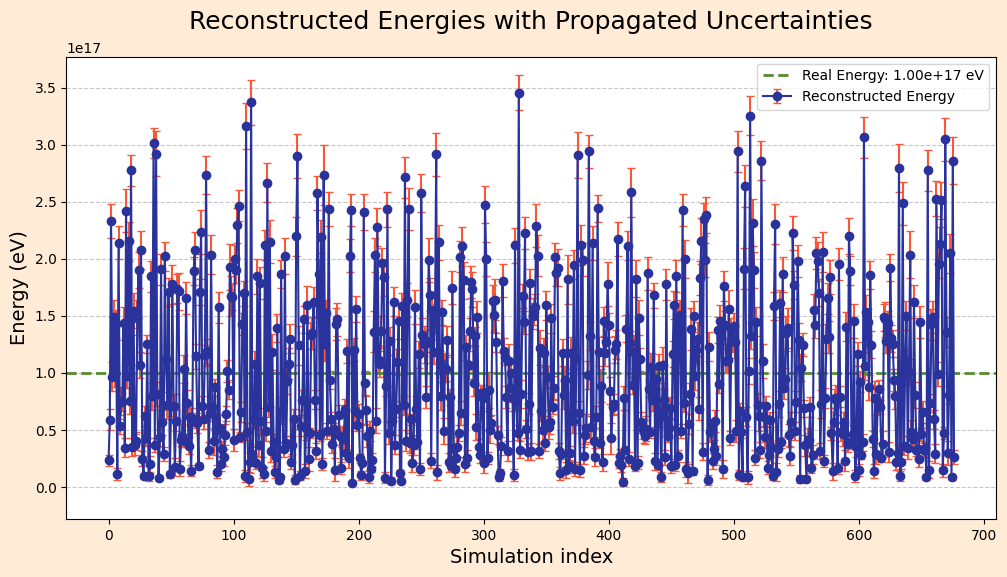

In [193]:
x = np.arange(len(E_nominal))  

plt.figure(figsize=(12, 6), facecolor='#FFEBD6')
ax = plt.gca()

plt.errorbar(
    x,
    E_nominal,
    yerr=E_error,
    fmt='-o',           
    color='#29339B',    
    ecolor='#F95738',   
    elinewidth=1.5,    
    capsize=3,          
    #alpha=0.7,          
    label='Reconstructed Energy'
)

plt.axhline(
    E_real,
    color='#548C2F',
    linestyle='--',
    linewidth=2,
    label=f'Real Energy: {E_real:.2e} eV'
)

plt.xlabel('Simulation index', size=14)
plt.ylabel('Energy (eV)', size=14)
plt.title('Reconstructed Energies with Propagated Uncertainties', size=18, pad=20)

# Adicionar legenda e grid
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(
    min(E_nominal) - 3 * np.mean(E_error),
    max(E_nominal) + 3 * np.mean(E_error)
)


plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_error_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')